In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
plt.style.use('ggplot')
plt.style.use("default")
fontdict = {'fontsize':16, 'fontname':'Times New Roman'}
title_fontdict = {'fontsize':20, 'fontweight':'bold','fontname':'Times New Roman'}

In [ ]:
df = pd. read_csv('Data/CFW_Police_Crime_Data_Points.csv')

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/1285464818.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd. read_csv('CFW_Police_Crime_Data_Points.csv')


In [99]:
df.head()

,X,Y,Case_No_Offense,Case_No,Reported_Date,Nature_Of_Call,From_Date,Offense,Offense_Desc,BLOCK_ADDRESS,...,intTotal,Location_1,GeoCodeScore,X_Coordinate,Y_Coordinate,Latitude,Longitude,LastUpdated,shape,OBJECTID
0,2.311272e+06,6.965270e+06,180107120-520,180107120,2018/12/02 17:24:47+00,PENAL CODE,2018/12/02 17:24:47+00,520,PC 42.12(B) Discharge Firearm Certain Munici 5...,4400 CHRISTINE RD,...,0,"(32.771041384088775, -97.384760197379791)",100,2.311272e+06,6.965270e+06,32.771041,-97.384760,2019/07/10 15:41:21+00,NaN,759641
1,2.303723e+06,6.945828e+06,180107126-240,180107126,2018/12/02 10:16:24+00,MISSING VEHICLE,2018/12/02 10:16:24+00,240,PC 31.07 Unauth Use of Vehicle 240 MOTOR VEHIC...,5800 FARNSWORTH AVE,...,0,"(32.717821190967946, -97.409974670024454)",100,2.303723e+06,6.945828e+06,32.717821,-97.409975,2019/07/10 15:41:21+00,NaN,759642
2,2.301387e+06,6.977183e+06,180107134-35A,180107134,2018/12/02 18:50:00+00,NARCOTIC VIOLATIONS,2018/12/02 18:50:00+00,35A,HSC 481.121(B)(1) Poss Marij <=2OZ 35A DRUG/NA...,6100 SAN VILLA DR,...,0,"(32.804069670366097, -97.416518648392923)",100,2.301387e+06,6.977183e+06,32.804070,-97.416519,2019/07/10 15:41:21+00,NaN,759643
3,2.296122e+06,6.952057e+06,180107137-40A,180107137,2018/12/02 18:00:00+00,PROSTITUTION,2018/12/02 18:00:00+00,40A,PC 43.02 Prostitution 40A PROSTITUTION 40040002,2700 GREEN OAKS RD,...,0,"(32.735155979744576, -97.434485509124784)",100,2.296122e+06,6.952057e+06,32.735156,-97.434486,2019/07/10 15:41:21+00,NaN,759644
4,2.303347e+06,6.914596e+06,180107167-13A,180107167,2018/12/02 20:36:55+00,AG ASSAULT,2018/12/02 20:36:55+00,13A,PC 22.02 (B)(1) Agg Assault Date/Family/House ...,7600 BRONCO CROSSING CT,...,0,"(32.63198832005493, -97.412249672947823)",100,2.303347e+06,6.914596e+06,32.631988,-97.412250,2019/07/10 15:41:21+00,NaN,759645


In [100]:
df["Reported_Date"].dtype

dtype('O')

In [101]:
df["Reported_Date"].isna().sum()

0

In [102]:
df['Date'] = pd.to_datetime(df['Reported_Date'], errors='coerce')

In [103]:
df.head(2)

,X,Y,Case_No_Offense,Case_No,Reported_Date,Nature_Of_Call,From_Date,Offense,Offense_Desc,BLOCK_ADDRESS,...,Location_1,GeoCodeScore,X_Coordinate,Y_Coordinate,Latitude,Longitude,LastUpdated,shape,OBJECTID,Date
0,2.311272e+06,6.965270e+06,180107120-520,180107120,2018/12/02 17:24:47+00,PENAL CODE,2018/12/02 17:24:47+00,520,PC 42.12(B) Discharge Firearm Certain Munici 5...,4400 CHRISTINE RD,...,"(32.771041384088775, -97.384760197379791)",100,2.311272e+06,6.965270e+06,32.771041,-97.384760,2019/07/10 15:41:21+00,NaN,759641,2018-12-02 17:24:47+00:00
1,2.303723e+06,6.945828e+06,180107126-240,180107126,2018/12/02 10:16:24+00,MISSING VEHICLE,2018/12/02 10:16:24+00,240,PC 31.07 Unauth Use of Vehicle 240 MOTOR VEHIC...,5800 FARNSWORTH AVE,...,"(32.717821190967946, -97.409974670024454)",100,2.303723e+06,6.945828e+06,32.717821,-97.409975,2019/07/10 15:41:21+00,NaN,759642,2018-12-02 10:16:24+00:00


In [104]:
len(df)

582369

## Remove October data (incomplete)

In [105]:
df = df[df['Date'] < '2025-10-01']
len(df)

580622

In [106]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

0

## Monthly Pattern

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/72574395.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')
/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/72574395.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()


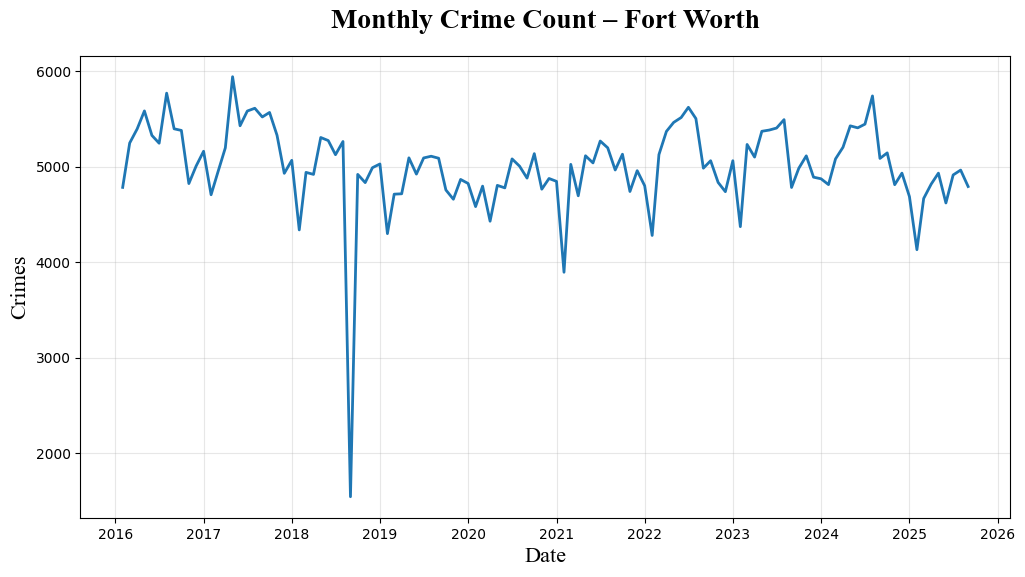

In [111]:
df2 = (
    df.resample('M', on='Date')
      .size()
      .reset_index(name='Crime_Count')
)

df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth', fontdict=title_fontdict, pad=20)
plt.xlabel('Date', fontdict=fontdict)
plt.ylabel('Crimes', fontdict=fontdict)
plt.grid(alpha=0.3)
plt.show()

#### Interplolate first to remove the 2018/09 (Sept) dip

In [112]:
# 1. Create monthly series
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_counts = (
    df.groupby('YearMonth')
      .size()
      .reset_index(name='Monthly_Crime')
)

monthly_counts['Timestamp'] = monthly_counts['YearMonth'].dt.to_timestamp()

# 2. Create time series index
ts = monthly_counts.set_index('Timestamp')['Monthly_Crime'].copy()

# 3. Replace bad month (September 2018) with NaN
ts.loc['2018-09'] = np.nan

# 4. Linear interpolation
ts_interpolated = ts.interpolate(method='linear')

# 5. Put interpolated values back into DF
monthly_counts['Monthly_Crime'] = ts_interpolated.values

# 6. Regenerate month column for later plots
monthly_counts['Month'] = monthly_counts['Timestamp'].dt.month_name()


/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/1454734339.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['YearMonth'] = df['Date'].dt.to_period('M')


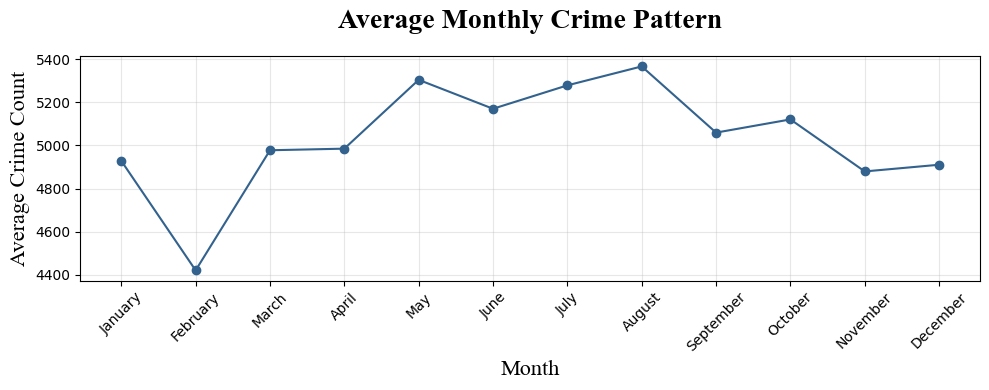

In [114]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

month_pattern = (
    monthly_counts.groupby('Month')['Monthly_Crime']
    .mean()
    .reindex(month_order)
    .reset_index(name='Avg_Monthly_Crime')
)

plt.figure(figsize=(10,4))
plt.plot(month_pattern['Month'], month_pattern['Avg_Monthly_Crime'], marker='o', color='#32628d')
plt.title("Average Monthly Crime Pattern", fontdict=title_fontdict, pad=20)
plt.xticks(rotation=45)
plt.ylabel("Average Crime Count", fontdict=fontdict)
plt.xlabel("Month", fontdict=fontdict)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



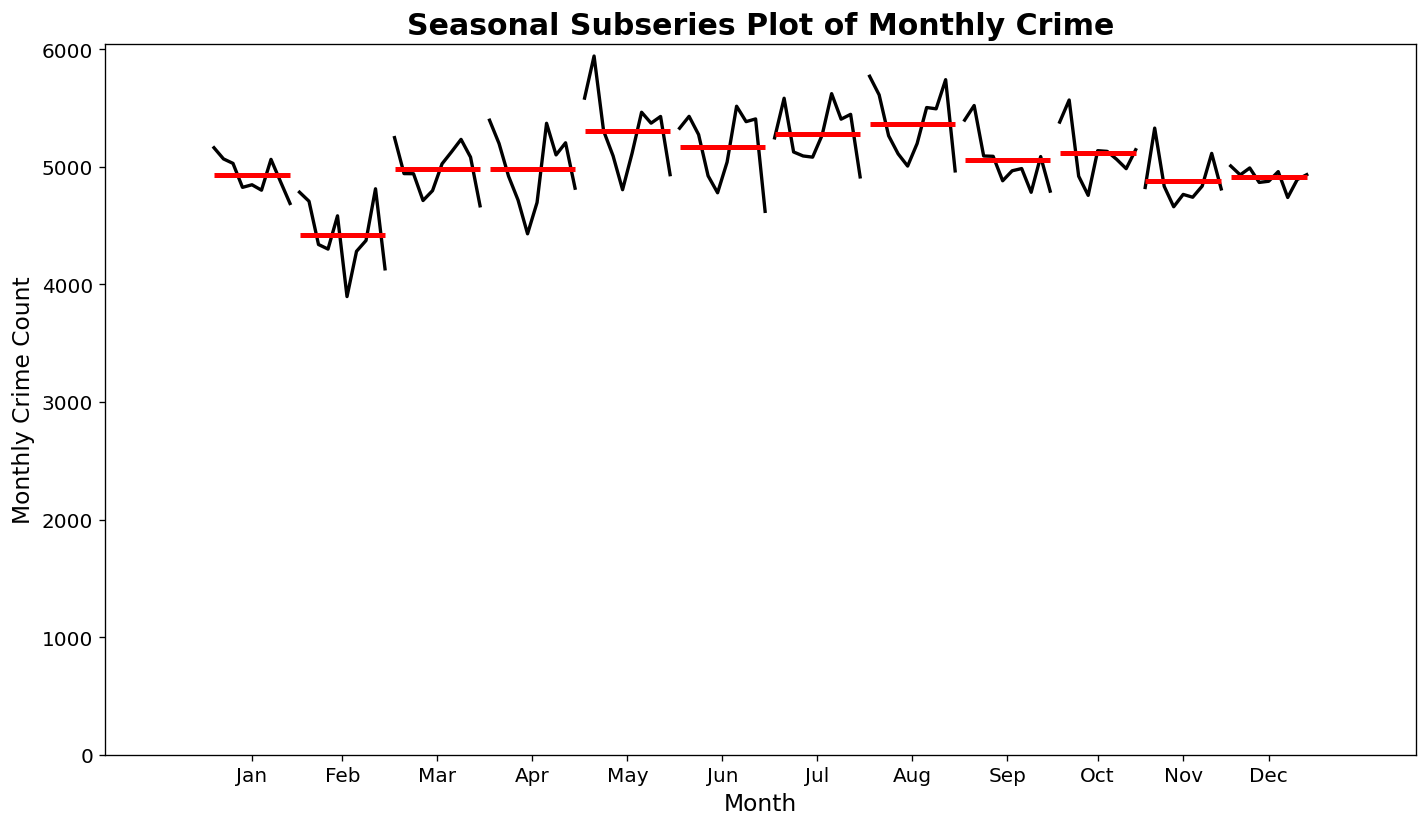

In [115]:
from statsmodels.graphics.tsaplots import month_plot
import matplotlib.pyplot as plt

# Prepare data
monthly = monthly_counts.copy()
monthly['Timestamp'] = monthly['YearMonth'].dt.to_timestamp()
ts = monthly.set_index('Timestamp')['Monthly_Crime']

# Create figure and axis manually
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

# Generate the month plot *on the axis we created*
month_plot(ts, ax=ax)

# Improve visual styling
ax.set_title("Seasonal Subseries Plot of Monthly Crime",
             fontsize=18, weight='bold')

ax.set_ylabel("Monthly Crime Count", fontsize=14)
ax.set_xlabel("Month", fontsize=14)

# Start y-axis at 0
ax.set_ylim(bottom=0)

# Improve the appearance of the lines
for line in ax.lines:
    if line.get_linestyle() == '-':     # monthly mean line
        line.set_color("black")
        line.set_linewidth(2)
    else:                                # individual years
        line.set_color("gray")
        line.set_alpha(0.7)
        line.set_linewidth(1.2)

# Better tick font sizes
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()


<Figure size 1440x960 with 0 Axes>

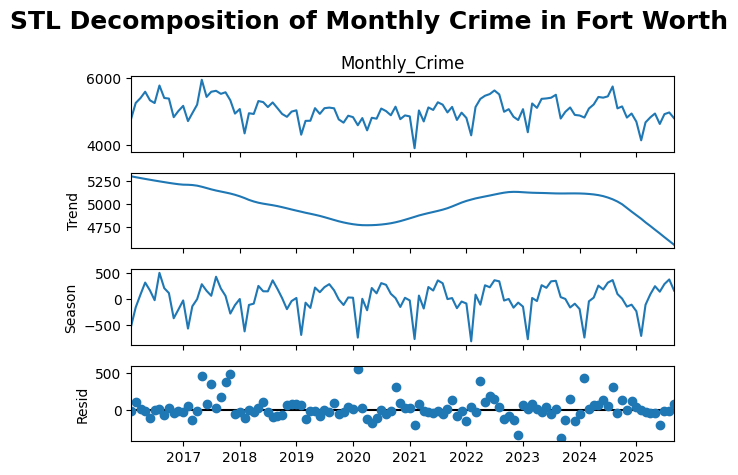

In [116]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Prepare monthly series
monthly = monthly_counts.copy()
monthly['Timestamp'] = monthly['YearMonth'].dt.to_timestamp()
ts = monthly.set_index('Timestamp')['Monthly_Crime']

# Run STL
stl = STL(ts, period=12, robust=True)
res = stl.fit()

# Plot
plt.figure(figsize=(12, 8), dpi=120)
res.plot()
plt.suptitle("STL Decomposition of Monthly Crime in Fort Worth", fontsize=18, weight='bold')
plt.tight_layout()
plt.show()


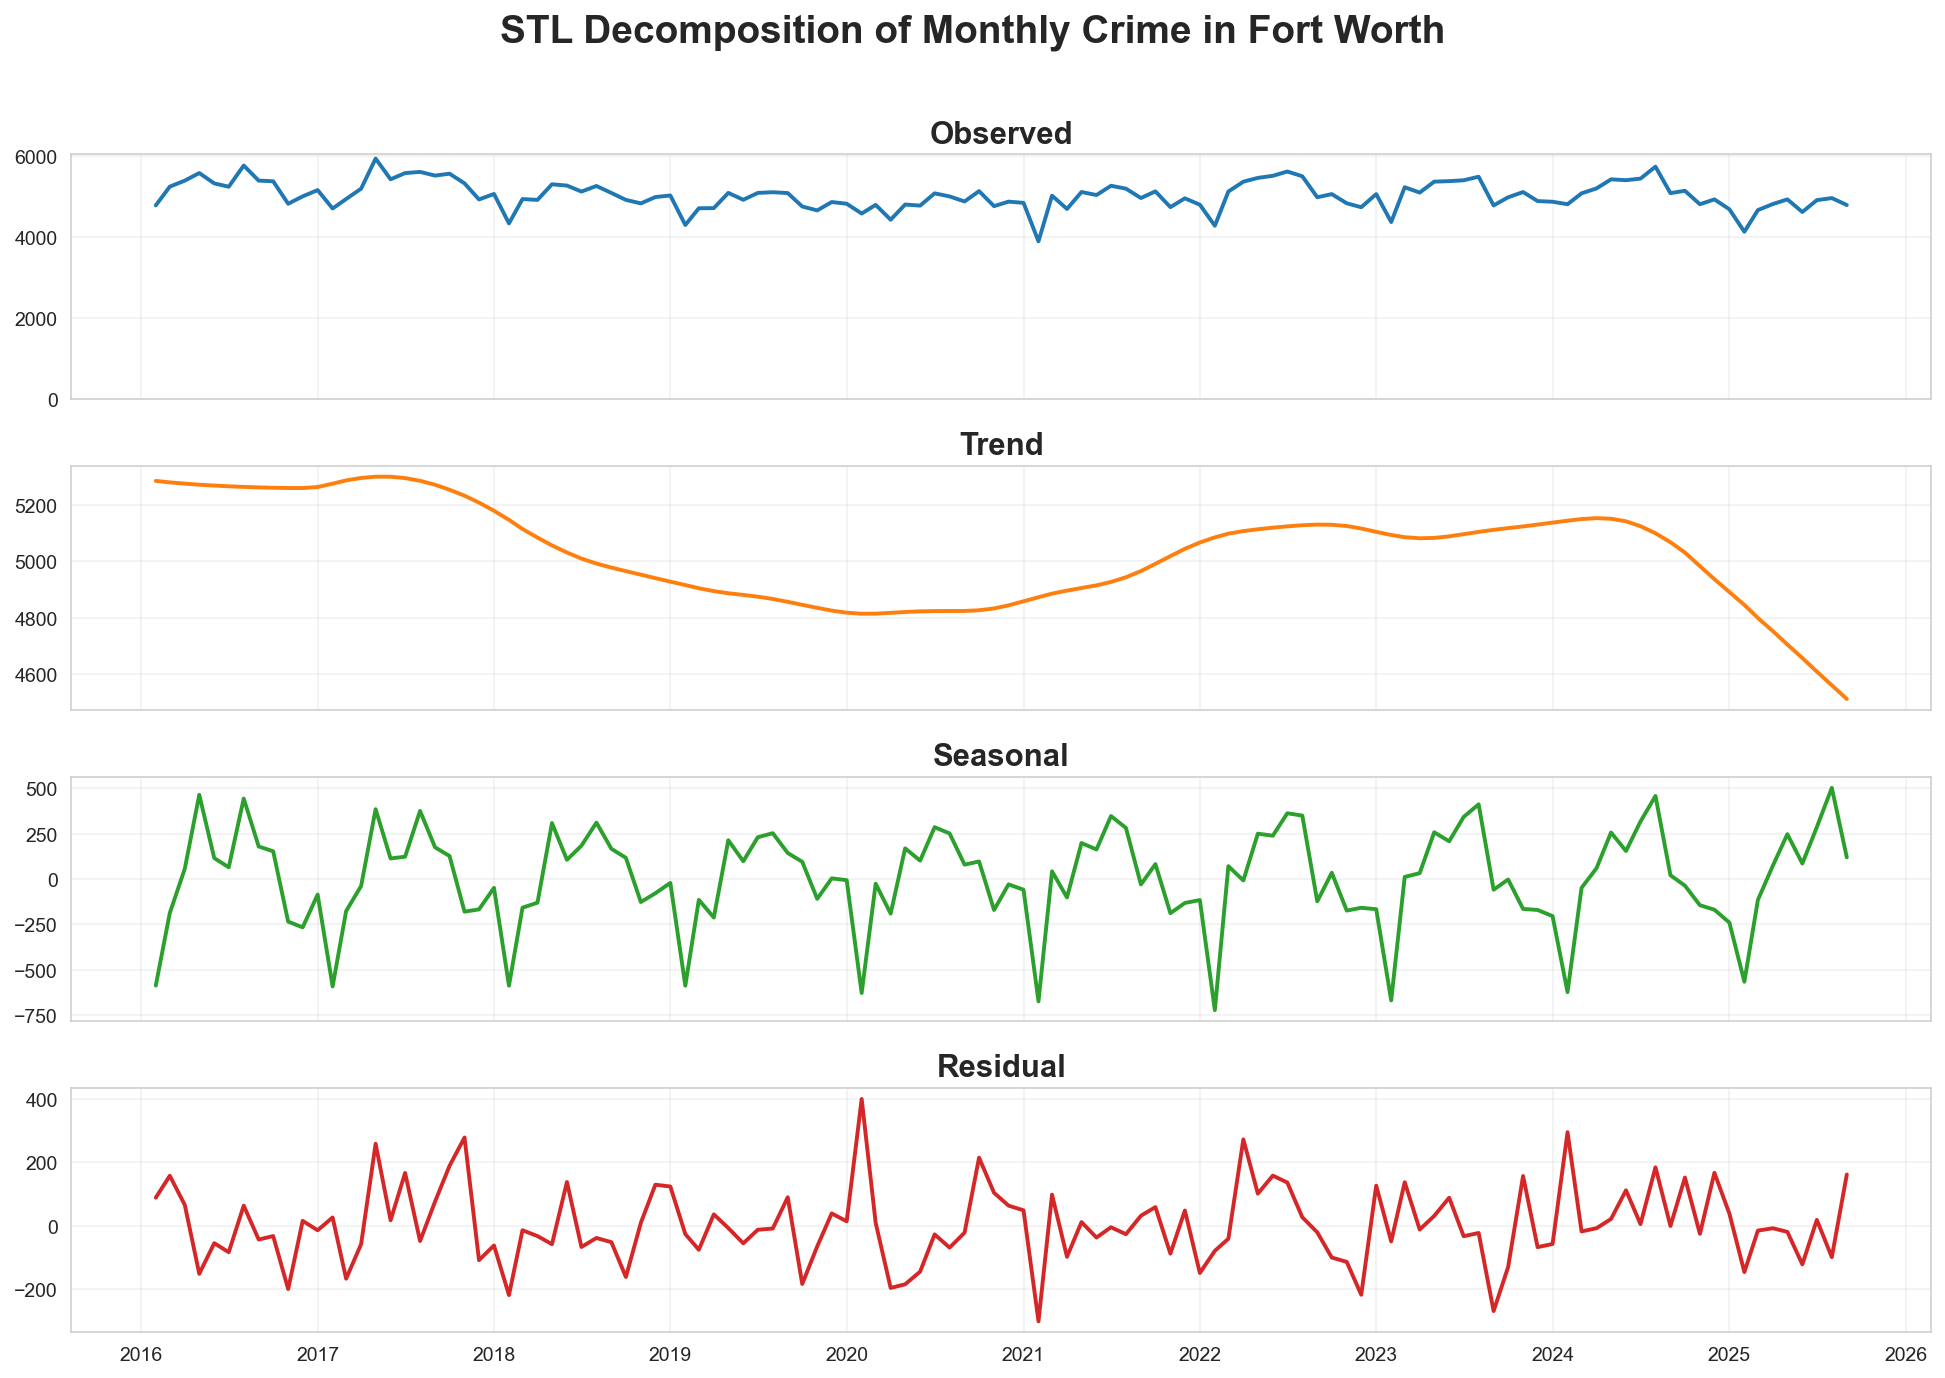

In [117]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean seaborn style
sns.set_style("whitegrid")

# Prepare monthly series
monthly = monthly_counts.copy()
# monthly['Timestamp'] = monthly['YearMonth'].dt.to_timestamp()
ts = monthly.set_index('Timestamp')['Monthly_Crime']

# Fit STL
stl = STL(ts, period=12)
res = stl.fit()

# Create nicer figure layout
fig, axes = plt.subplots(4, 1, figsize=(14, 10), dpi=140, sharex=True)

components = {
    "Observed": res.observed,
    "Trend": res.trend,
    "Seasonal": res.seasonal,
    "Residual": res.resid
}

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # blue, orange, green, red

for ax, (title, series), color in zip(axes, components.items(), colors):
    ax.plot(series.index, series.values, color=color, linewidth=2)
    ax.set_title(title, fontsize=16, weight='bold')
    ax.grid(alpha=0.3)
    if title == "Observed":  
        ax.set_ylim(bottom=0)


# Global title
plt.suptitle("STL Decomposition of Monthly Crime in Fort Worth",
             fontsize=20, weight="bold", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [95]:
from scipy.stats import skew, kurtosis
import pandas as pd

series = monthly_counts['Monthly_Crime']

summary_stats = series.describe()

cv = series.std() / series.mean()
skewness = skew(series)
kurt = kurtosis(series)

summary_table = pd.DataFrame({
    'Statistic': [
        'Count (months)', 'Mean', 'Median', 'Std Dev', 'Min', 'Max',
        '25th Percentile', '75th Percentile', 'IQR',
        'Coefficient of Variation', 'Skewness', 'Kurtosis'
    ],
    'Value': [
        summary_stats['count'],
        summary_stats['mean'],
        summary_stats['50%'],
        summary_stats['std'],
        summary_stats['min'],
        summary_stats['max'],
        summary_stats['25%'],
        summary_stats['75%'],
        summary_stats['75%'] - summary_stats['25%'],  # IQR
        cv,
        skewness,
        kurt
    ]
})

print(summary_table)



                   Statistic        Value
0             Count (months)   116.000000
1                       Mean  5035.922414
2                     Median  5027.000000
3                    Std Dev   345.975223
4                        Min  3896.000000
5                        Max  5942.000000
6            25th Percentile  4816.750000
7            75th Percentile  5265.250000
8                        IQR   448.500000
9   Coefficient of Variation     0.068701
10                  Skewness    -0.230386
11                  Kurtosis     0.643906


In [96]:
summary_table.to_csv('monthly_crime_summary_stats.csv', index=False)

## Monthly Grouping (Done)

In [59]:
df2 = (
    df.resample('M', on='Date')
      .size()
      .reset_index(name='Crime_Count')
)

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/3654985779.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')


In [ ]:
df2 = (
    df.resample('M', on='Date')
      .size()
      .reset_index(name='Crime_Count')
)
df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()
df2.loc[(df2['Date'].dt.year == 2018) &
        (df2['Date'].dt.month.isin([9])), 'Crime_Count'] = np.nan

df2['Crime_Count'] = df2['Crime_Count'].interpolate(method='linear')



/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/2327292478.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='Date')
/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/2327292478.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()


In [60]:
df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_47598/2553353924.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df2['Date'] = df2['Date'].dt.to_period('M').dt.to_timestamp()


In [11]:
df2.head()

,Date,Crime_Count
0,2016-02-01,4784
1,2016-03-01,5248
2,2016-04-01,5396
3,2016-05-01,5584
4,2016-06-01,5328


In [12]:
df2.tail()

,Date,Crime_Count
112,2025-06-01,4621
113,2025-07-01,4914
114,2025-08-01,4965
115,2025-09-01,4793
116,2025-10-01,1747


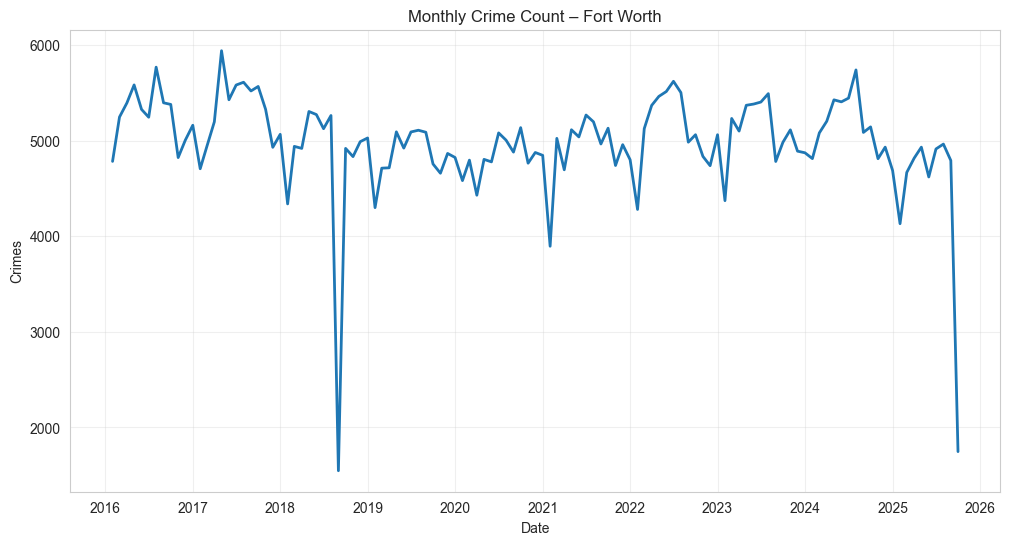

In [61]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

In [64]:
df2 = df2[:-1]
df2.tail()

,Date,Crime_Count
111,2025-05-01,4933
112,2025-06-01,4621
113,2025-07-01,4914
114,2025-08-01,4965
115,2025-09-01,4793


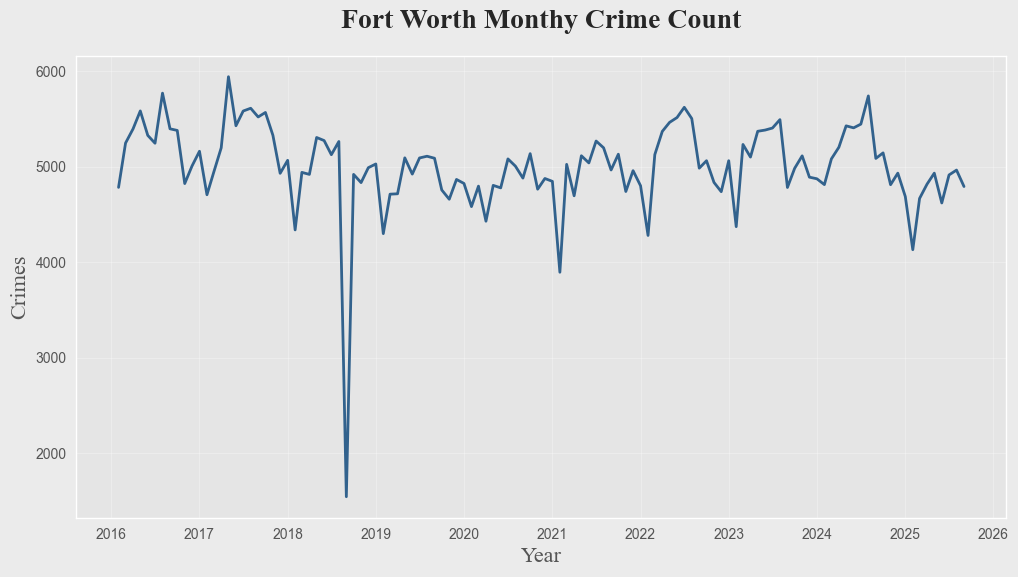

In [65]:

plt.style.use('ggplot')
fontdict = {'fontsize':16, 'fontname':'Times New Roman'}
title_fontdict = {'fontsize':20, 'fontweight':'bold','fontname':'Times New Roman'}

plt.figure(figsize=(12,6), facecolor=(.92, .92, .92))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2, color='#32628d')

plt.title('Fort Worth Monthy Crime Count', fontdict=title_fontdict, pad=20)
plt.xlabel('Year', fontdict=fontdict)
plt.ylabel('Crimes', fontdict=fontdict)
plt.grid(alpha=0.3)
plt.show()

In [23]:
# df[df['Date'].dt.to_period('M') == '2018-07'].shape
# df[df['Date'].dt.to_period('M') == '2018-08'].shape
df[df['Date'].dt.to_period('M') == '2018-09'].shape
# df[df['Date'].dt.to_period('M') == '2018-10'].shape
# df[df['Date'].dt.to_period('M') == '2018-11'].shape
# df[df['Date'].dt.to_period('M') == '2018-12'].shape

/var/folders/hs/7nqw1trd4wl1z4jpq6rkvq740000gn/T/ipykernel_93950/1796933729.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[df['Date'].dt.to_period('M') == '2018-09'].shape


(1547, 32)

<Axes: xlabel='Date'>

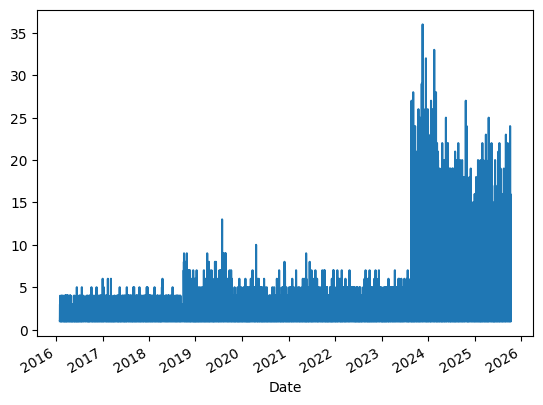

In [24]:
df['Date'].value_counts().sort_index().plot()


In [25]:
df2.loc[(df2['Date'].dt.year == 2018) &
        (df2['Date'].dt.month.isin([9])), 'Crime_Count'] = np.nan


In [26]:
df2['Crime_Count'] = df2['Crime_Count'].interpolate(method='linear')

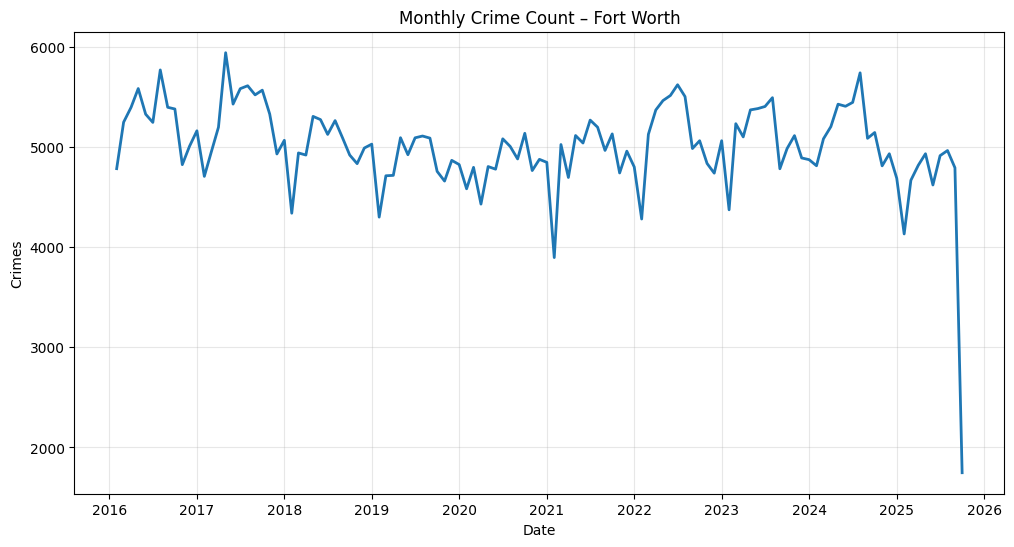

In [27]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()

In [27]:
len(df2)

117

In [ ]:
tempr = pd.read_csv('Data/CFW-Avg-Tepmr.csv')
tempr.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,2025,42.9,49.3,64.0,67.9,74.1,82.4,85.5,85.5,80.8,73.4,NaN,NaN,NaN
1,2024,43.0,57.7,61.8,68.7,77.3,84.2,85.1,88.9,79.3,75.7,61.7,53.7,69.8
2,2023,52.1,52.4,60.7,65.3,75.6,84.0,89.3,92.9,84.6,69.2,57.8,52.8,69.7
3,2022,45.8,46.2,58.5,69.5,77.9,86.1,91.8,86.8,80.6,69.1,55.0,50.7,68.2
4,2021,47.5,41.1,61.4,64.6,71.8,82.1,84.7,85.1,80.5,72.0,57.7,61.3,67.5


In [29]:
df_temp = tempr.drop(columns=['Total'], errors='ignore')

# Melt from wide → long format
df_long = df_temp.melt(id_vars='Year', var_name='Month', value_name='Temp')

# Map month abbreviations to month numbers
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

df_long['Month'] = df_long['Month'].map(month_map)

# Create a proper datetime column
df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'],
                                      month=df_long['Month'],
                                      day=1))

# Sort chronologically
df_long = df_long.sort_values('Date').reset_index(drop=True)

# Final clean format
df_temp = df_long[['Date', 'Temp']]

In [30]:
df_temp.head()

,Date,Temp
0,2016-01-01,47.0
1,2016-02-01,55.2
2,2016-03-01,61.2
3,2016-04-01,68.1
4,2016-05-01,72.5


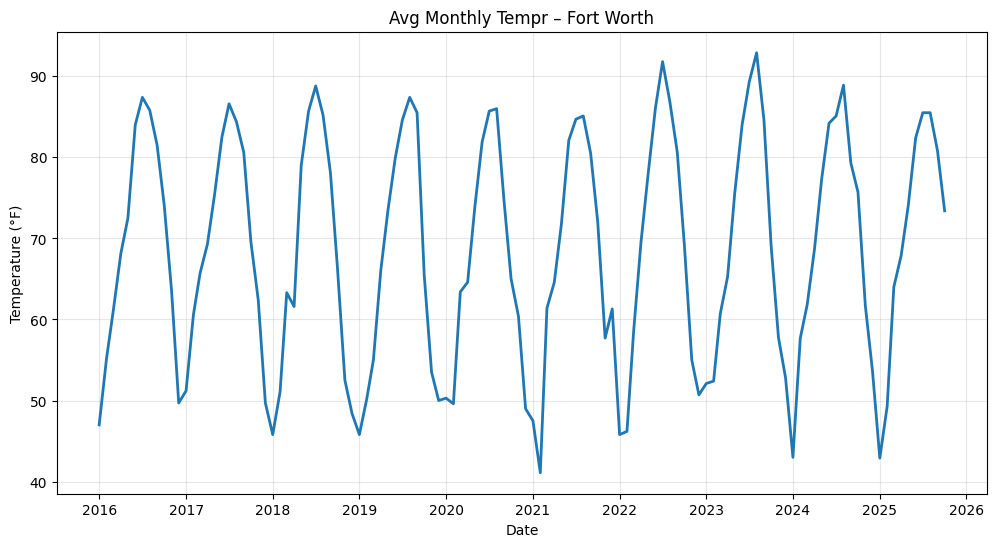

In [32]:
plt.figure(figsize=(12,6))
plt.plot(df_temp['Date'], df_temp['Temp'], linewidth=2)

plt.title('Avg Monthly Tempr – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.grid(alpha=0.3)
plt.show()

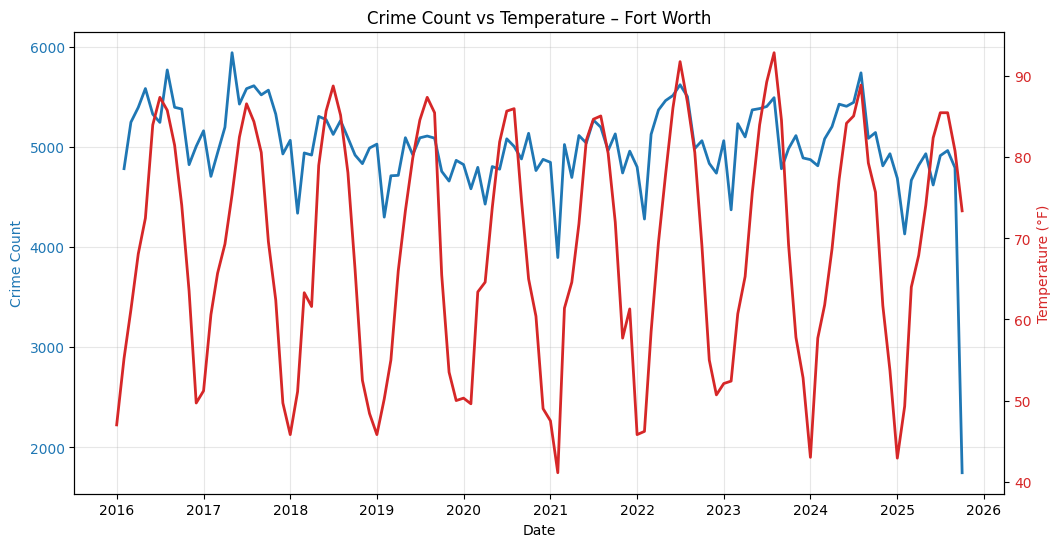

In [33]:
fig, ax1 = plt.subplots(figsize=(12,6))

# --- First Y-axis (Crime) ---
ax1.plot(df2['Date'], df2['Crime_Count'], color='tab:blue', linewidth=2, label='Crime Count')
ax1.set_xlabel('Date')
ax1.set_ylabel('Crime Count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# --- Second Y-axis (Temperature) ---
ax2 = ax1.twinx()
ax2.plot(df_temp['Date'], df_temp['Temp'], color='tab:red', linewidth=2, label='Temperature (°F)')
ax2.set_ylabel('Temperature (°F)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Title + grid
plt.title('Crime Count vs Temperature – Fort Worth')
ax1.grid(alpha=0.3)

plt.show()


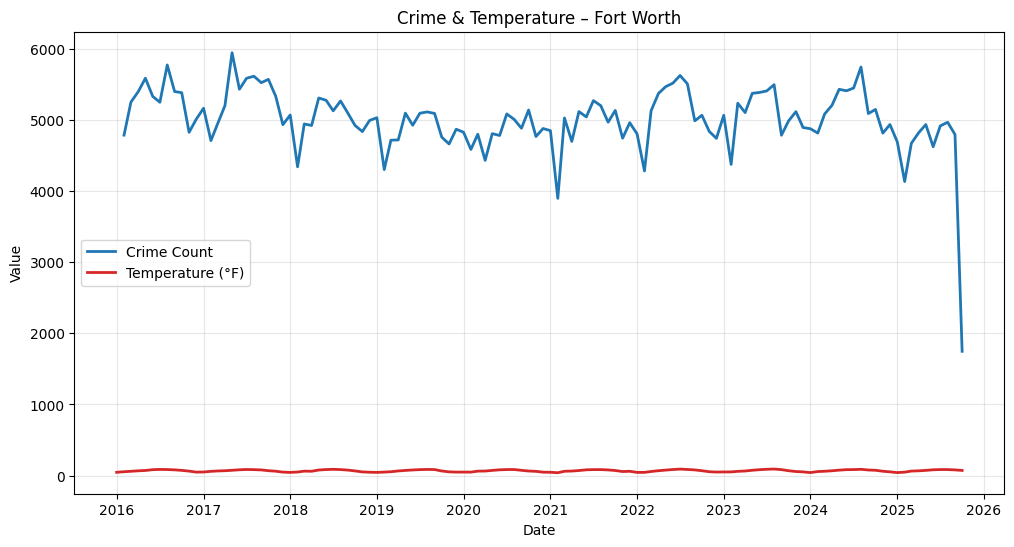

In [34]:
plt.figure(figsize=(12,6))

plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2, label='Crime Count', color='tab:blue')
plt.plot(df_temp['Date'], df_temp['Temp'], linewidth=2, label='Temperature (°F)', color='tab:red')

plt.title('Crime & Temperature – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [35]:
df2.tail()

,Date,Crime_Count
112,2025-06-01,4621.0
113,2025-07-01,4914.0
114,2025-08-01,4965.0
115,2025-09-01,4793.0
116,2025-10-01,1747.0


### Removing last element 

In [28]:
df2 = df2[:-1]


In [29]:
df2.tail()

,Date,Crime_Count
111,2025-05-01,4933.0
112,2025-06-01,4621.0
113,2025-07-01,4914.0
114,2025-08-01,4965.0
115,2025-09-01,4793.0


In [40]:
df2.to_csv('CFW_Monthly_Crime_Count_Cleaned.csv', index=False)

In [41]:
df_temp.tail()

,Date,Temp
115,2025-08-01,85.5
116,2025-09-01,80.8
117,2025-10-01,73.4
118,2025-11-01,NaN
119,2025-12-01,NaN


In [42]:
df_temp = df_temp[:-2]
df_temp.tail()

,Date,Temp
113,2025-06-01,82.4
114,2025-07-01,85.5
115,2025-08-01,85.5
116,2025-09-01,80.8
117,2025-10-01,73.4


In [43]:
df_temp.to_csv('CFW_Avg_Tempr_Cleaned.csv', index=False)

# Monthly Analysis From Here

In [ ]:
df2 = pd.read_csv('Data/Cleaned/CFW_Monthly_Crime_Count_Cleaned.csv')
df2['Date'] = pd.to_datetime(df2['Date'])
df2.head()

,Date,Crime_Count
0,2016-02-01,4784.0
1,2016-03-01,5248.0
2,2016-04-01,5396.0
3,2016-05-01,5584.0
4,2016-06-01,5328.0


In [42]:
df2.head()

,Date,Crime_Count
0,2016-02-01,4784.0
1,2016-03-01,5248.0
2,2016-04-01,5396.0
3,2016-05-01,5584.0
4,2016-06-01,5328.0


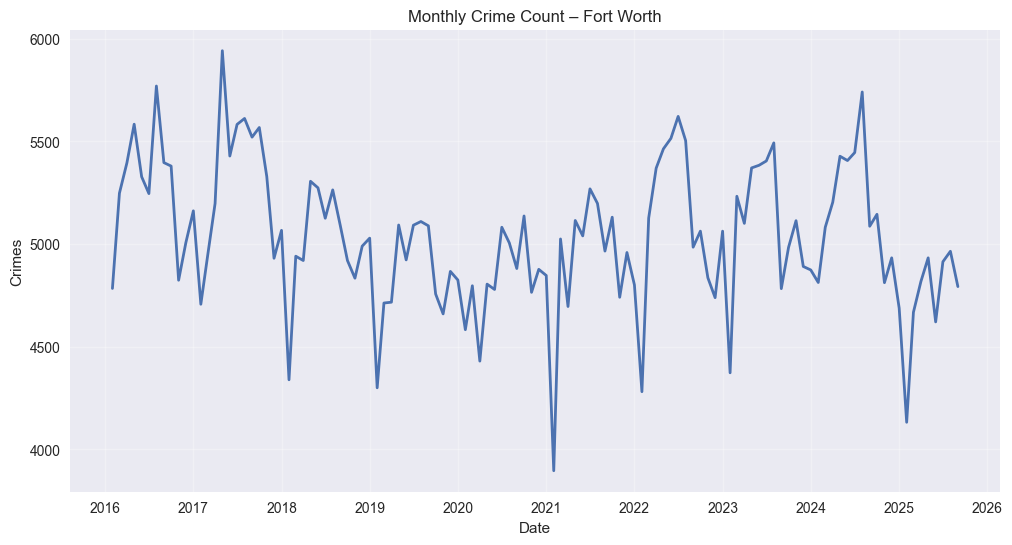

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Crime_Count'], linewidth=2)

plt.title('Monthly Crime Count – Fort Worth')
plt.xlabel('Date')
plt.ylabel('Crimes')
plt.grid(alpha=0.3)
plt.show()


In [44]:
from pmdarima.arima.utils import ndiffs, nsdiffs

y = df2['Crime_Count']

# Regular differencing (ADF / KPSS)
d_adf = ndiffs(y, test='adf')
d_kpss = ndiffs(y, test='kpss')
d_pp   = ndiffs(y, test='pp')

print("Recommended d (ADF):", d_adf)
print("Recommended d (KPSS):", d_kpss)
print("Recommended d (PP):", d_pp)

# Seasonal differencing (OCSB test)
D = nsdiffs(y, m=12, test='ch')
print("Recommended D:", D)


Recommended d (ADF): 0
Recommended d (KPSS): 0
Recommended d (PP): 0
Recommended D: 0


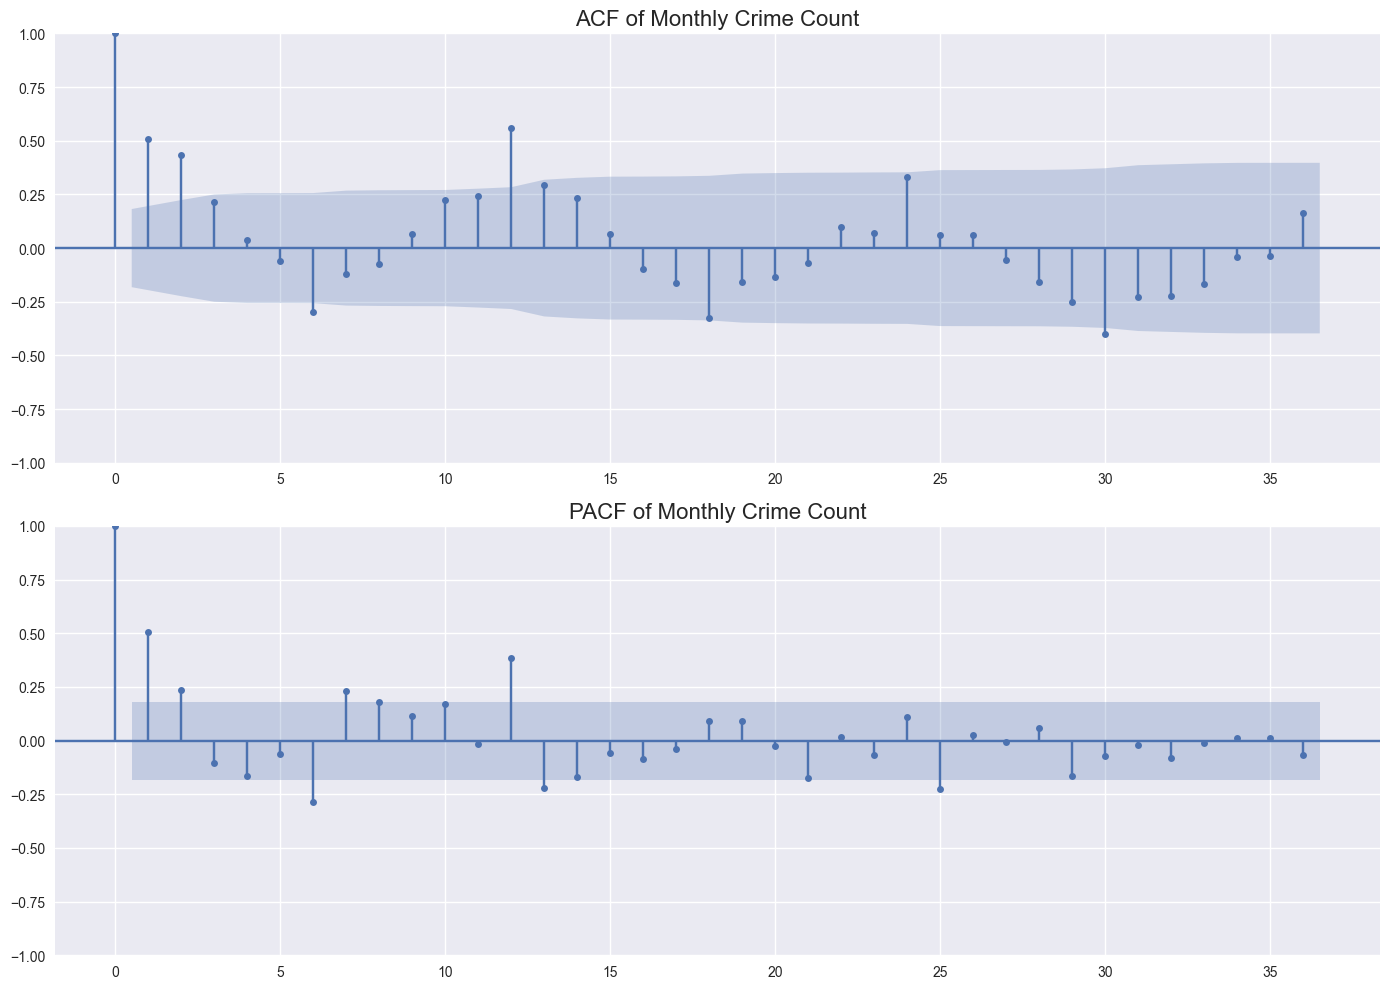

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots(2, 1, figsize=(14,10))

# ACF
plot_acf(y, ax=ax[0], lags=36)       # 3 years worth of lags
ax[0].set_title("ACF of Monthly Crime Count", fontsize=16)

# PACF
plot_pacf(y, ax=ax[1], lags=36, method='ywm') 
ax[1].set_title("PACF of Monthly Crime Count", fontsize=16)

plt.tight_layout()
plt.show()

In [46]:
import pmdarima as pm

auto_model = pm.auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,              # let it find d
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=None,              # let it find D (or set D=1 if you want to force)
    m=12,                # monthly seasonality
    seasonal=True,
    stepwise=True,
    trace=True,          # prints the tried models
    information_criterion='aicc',
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
print("Selected (p,d,q):", auto_model.order)
print("Selected (P,D,Q,m):", auto_model.seasonal_order)

Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AICC=1688.653, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AICC=1628.729, Time=0.48 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AICC=1638.643, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AICC=2309.420, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AICC=1656.326, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AICC=1634.589, Time=0.91 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AICC=1628.580, Time=0.43 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AICC=1626.254, Time=0.21 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AICC=1609.712, Time=0.78 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AICC=1635.132, Time=1.35 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AICC=1637.322, Time=0.56 sec
 ARIMA(2,0,0)(0,0,2)[12] intercept   : AICC=1607.791, Time=0.90 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AICC=1618.882, Time=0.18 sec
 ARIMA(2,0,0)(1,0,2)[12] intercept   : AICC=1625.022, Time=1.53 sec
 ARI

In [47]:
auto_model_2 = pm.auto_arima(
    y,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None,              # let it find d
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=None,              # let it find D (or set D=1 if you want to force)
    m=12,                # monthly seasonality
    seasonal=True,
    stepwise=False,
    trace=True,          # prints the tried models
    information_criterion='aicc',
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())
print("Selected (p,d,q):", auto_model.order)
print("Selected (P,D,Q,m):", auto_model.seasonal_order)

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AICC=1688.653, Time=0.02 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AICC=1653.725, Time=0.47 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AICC=1637.322, Time=0.76 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AICC=1690.591, Time=0.04 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AICC=1655.939, Time=0.28 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AICC=1653.298, Time=1.29 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AICC=1683.152, Time=0.70 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AICC=inf, Time=0.69 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AICC=inf, Time=1.37 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AICC=1669.949, Time=0.05 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AICC=1638.643, Time=0.20 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AICC=1619.848, Time=0.93 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AICC=1671.596, Time=0.17 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AICC=1645.323, Time=0.32 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AICC=1643.003, Time

In [49]:
print(auto_model.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  116
Model:             SARIMAX(2, 0, 0)x(0, 0, [1, 2], 12)   Log Likelihood                -797.510
Date:                                 Fri, 28 Nov 2025   AIC                           1607.020
Time:                                         01:39:18   BIC                           1623.542
Sample:                                              0   HQIC                          1613.727
                                                 - 116                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1866.3609    583.708      3.197      0.001     722.315    3010

In [90]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(2,0,1)(0,1,0)[12]
model_manual = SARIMAX(
    y,
    # order=(1, 0, 2), # 1210
    # order=(1, 0, 1), # 1222
    # order=(2, 0, 2), # 1212
    # order=(2, 1, 2), # 1201
    # order=(2, 1, 1), # 1212
    # order=(2, 1, 2), # 1201
    # seasonal_order=(0, 1, 1, 12),
    order=(0, 1, 2),
    seasonal_order=(0, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_manual = model_manual.fit()
# print(results_manual.summary())

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.57073D+00    |proj g|=  3.57008D-01

At iterate    5    f=  4.45310D+00    |proj g|=  7.89516D-03

At iterate   10    f=  4.45270D+00    |proj g|=  8.33871D-04

At iterate   15    f=  4.45153D+00    |proj g|=  3.11101D-02

At iterate   20    f=  4.42932D+00    |proj g|=  4.79310D-02

At iterate   25    f=  4.42728D+00    |proj g|=  8.69283D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     28     30      1     0     0   

In [91]:
print(results_manual.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Crime_Count   No. Observations:                  116
Model:             SARIMAX(0, 1, 2)x(0, 1, 2, 12)   Log Likelihood                -513.565
Date:                            Fri, 28 Nov 2025   AIC                           1037.129
Time:                                    03:17:43   BIC                           1048.783
Sample:                                         0   HQIC                          1041.787
                                            - 116                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5938      0.123     -4.831      0.000      -0.835      -0.353
ma.L2          0.0397      0.121   

In [92]:
def calculate_aicc(model_results):
    """
    model_results: fitted SARIMAX results
    """
    llf = model_results.llf                   # log-likelihood
    n = model_results.nobs
    k = model_results.params.size             # number of parameters
    
    aic = model_results.aic
    aicc = aic + (2*k*(k+1)) / (n - k - 1)
    return aicc

aicc_value = calculate_aicc(results_manual)
print("AICc:", aicc_value)

AICc: 1037.6747199162855


In [83]:
import warnings

def aicc(result):
    """
    Compute AICc for a statsmodels SARIMAX results object.
    """
    aic = result.aic
    k = result.params.size        # number of parameters
    n = result.nobs               # number of observations
    if n - k - 1 <= 0:
        return np.inf
    return aic + (2 * k * (k + 1)) / (n - k - 1)

warnings.filterwarnings("ignore")

def sarima_search(y, 
                  p_range=(0,3), d_range=(0,1), q_range=(0,3),
                  P_range=(0,2), D=1, Q_range=(0,2),
                  m=12):
    """
    Custom AICc-based SARIMA grid search.
    y: pandas Series indexed by datetime with monthly freq.
    """
    best_model = None
    best_aicc = np.inf
    best_order = None
    best_seasonal_order = None
    
    results_table = []   # to store all models

    for p in range(p_range[0], p_range[1] + 1):
        for d in range(d_range[0], d_range[1] + 1):
            for q in range(q_range[0], q_range[1] + 1):
                for P in range(P_range[0], P_range[1] + 1):
                    for Q in range(Q_range[0], Q_range[1] + 1):

                        seasonal_order = (P, D, Q, m)
                        order = (p, d, q)

                        try:
                            model = SARIMAX(
                                y, 
                                order=order, 
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            result = model.fit(disp=False)

                            current_aicc = aicc(result)

                            results_table.append({
                                "order": order,
                                "seasonal_order": seasonal_order,
                                "aicc": current_aicc
                            })

                            if current_aicc < best_aicc:
                                best_aicc = current_aicc
                                best_model = result
                                best_order = order
                                best_seasonal_order = seasonal_order

                        except Exception as e:
                            continue

    # Convert table to DataFrame
    results_df = pd.DataFrame(results_table)
    results_df = results_df.sort_values("aicc").reset_index(drop=True)
    
    return best_model, best_order, best_seasonal_order, best_aicc, results_df


y = df2['Crime_Count']

best_model, best_order, best_seasonal_order, best_aicc, results_df = sarima_search(
    y,
    p_range=(0,3),
    d_range=(0,1),
    q_range=(0,3),
    P_range=(0,2),
    D=1,                 # FORCE seasonal differencing (recommended)
    Q_range=(0,2),
    m=12
)

print("Best Non-Seasonal Order (p,d,q):", best_order)
print("Best Seasonal Order (P,D,Q,m):", best_seasonal_order)
print("Best AICc:", best_aicc)
print(best_model.summary())

Best Non-Seasonal Order (p,d,q): (0, 1, 3)
Best Seasonal Order (P,D,Q,m): (0, 1, 2, 12)
Best AICc: 1026.4689179923555
                                        SARIMAX Results                                        
Dep. Variable:                             Crime_Count   No. Observations:                  116
Model:             SARIMAX(0, 1, 3)x(0, 1, [1, 2], 12)   Log Likelihood                -506.849
Date:                                 Fri, 28 Nov 2025   AIC                           1025.698
Time:                                         03:13:31   BIC                           1039.603
Sample:                                              0   HQIC                          1031.250
                                                 - 116                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [85]:
results_df.head(15)

,order,seasonal_order,aicc
0,"(0, 1, 3)","(0, 1, 2, 12)",1026.468918
1,"(0, 1, 3)","(2, 1, 2, 12)",1027.086458
2,"(0, 1, 3)","(1, 1, 2, 12)",1028.690176
3,"(1, 1, 3)","(0, 1, 2, 12)",1028.884506
4,"(1, 1, 3)","(2, 1, 2, 12)",1029.202635
5,"(1, 1, 3)","(1, 1, 2, 12)",1030.342576
6,"(2, 1, 3)","(0, 1, 2, 12)",1031.122609
7,"(2, 1, 3)","(2, 1, 2, 12)",1032.758962
8,"(2, 1, 3)","(1, 1, 2, 12)",1032.964093
9,"(3, 1, 3)","(0, 1, 2, 12)",1033.451663


### Forecast 

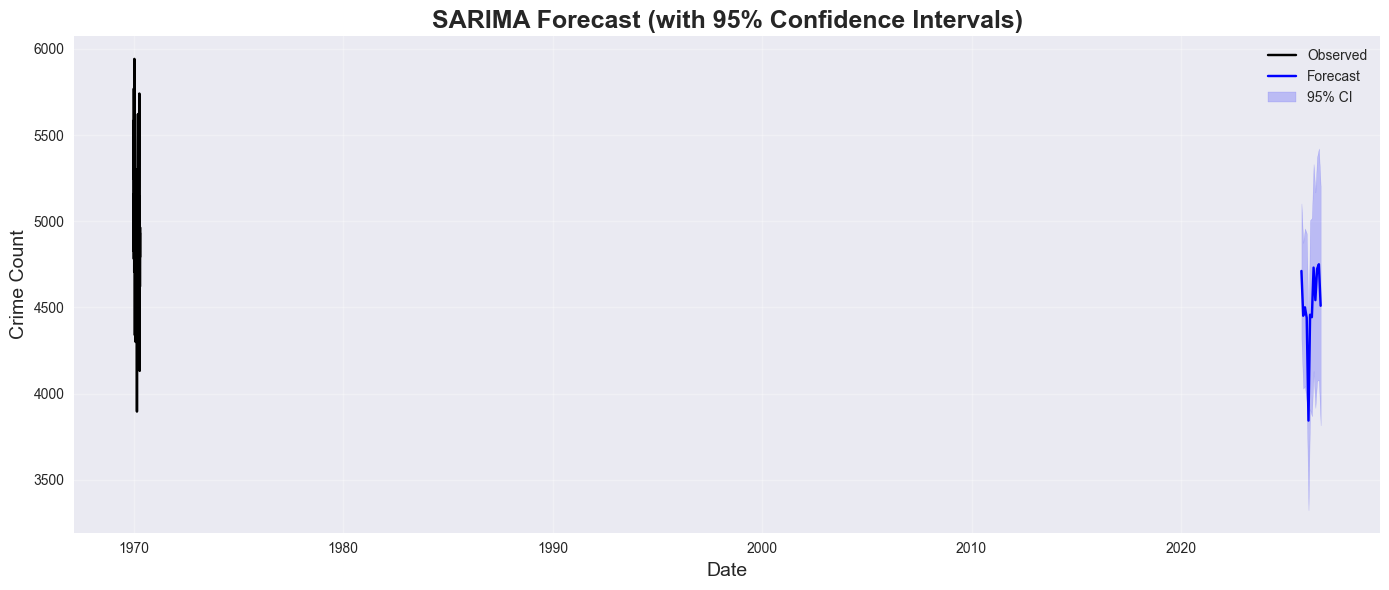

In [94]:
best_model = results_manual   # or whatever variable your fitted SARIMAX model is stored in
y = df2['Crime_Count']

n_forecast = 12

forecast_obj = best_model.get_forecast(steps=n_forecast)
forecast_mean = forecast_obj.predicted_mean
forecast_ci = forecast_obj.conf_int()

# future_index = pd.date_range(
#     start=y.index[-1] + pd.offsets.MonthEnd(1),
#     periods=n_forecast,
#     freq='M'
# )

future_index = pd.date_range(
    start=df2['Date'].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=n_forecast,
    freq='M'
)


plt.figure(figsize=(14,6))

# Plot history
plt.plot(y.index, y, label='Observed', color='black')

# Plot forecast mean
plt.plot(future_index, forecast_mean, label='Forecast', color='blue')

# Plot 95% CI
plt.fill_between(
    future_index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='blue',
    alpha=0.2,
    label='95% CI'
)

plt.title("SARIMA Forecast (with 95% Confidence Intervals)", fontsize=18, weight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Crime Count", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [95]:

def plot_sarima_forecast(
    model, 
    y, 
    steps=12, 
    show_ci=True, 
    ci_alpha=0.2,
    figsize=(14,6)
):
    """
    Plot SARIMA forecast with optional confidence intervals.

    model   : fitted SARIMAX results object
    y       : pandas Series with DatetimeIndex (monthly)
    steps   : how many months to forecast
    show_ci : whether to draw CI bands
    ci_alpha: transparency of CI band
    figsize : figure size tuple
    """

    # Forecast
    forecast_obj = model.get_forecast(steps=steps)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci = forecast_obj.conf_int()

    # Build future index (safe, no MonthEnd issues)
    future_index = pd.date_range(
        start=y.index[-1],
        periods=steps + 1,
        freq='M'
    )[1:]

    # Plot
    plt.figure(figsize=figsize)
    
    # historical data
    plt.plot(y.index, y, color='black', label='Observed', linewidth=2)

    # forecast line
    plt.plot(future_index, forecast_mean, color='red', label='Forecast', linewidth=2)

    # confidence intervals
    if show_ci:
        plt.fill_between(
            future_index,
            forecast_ci.iloc[:,0],
            forecast_ci.iloc[:,1],
            color='red',
            alpha=ci_alpha,
            label='95% CI'
        )

    # styling
    plt.title("SARIMA Forecast", fontsize=18, weight='bold')
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Crime Count", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


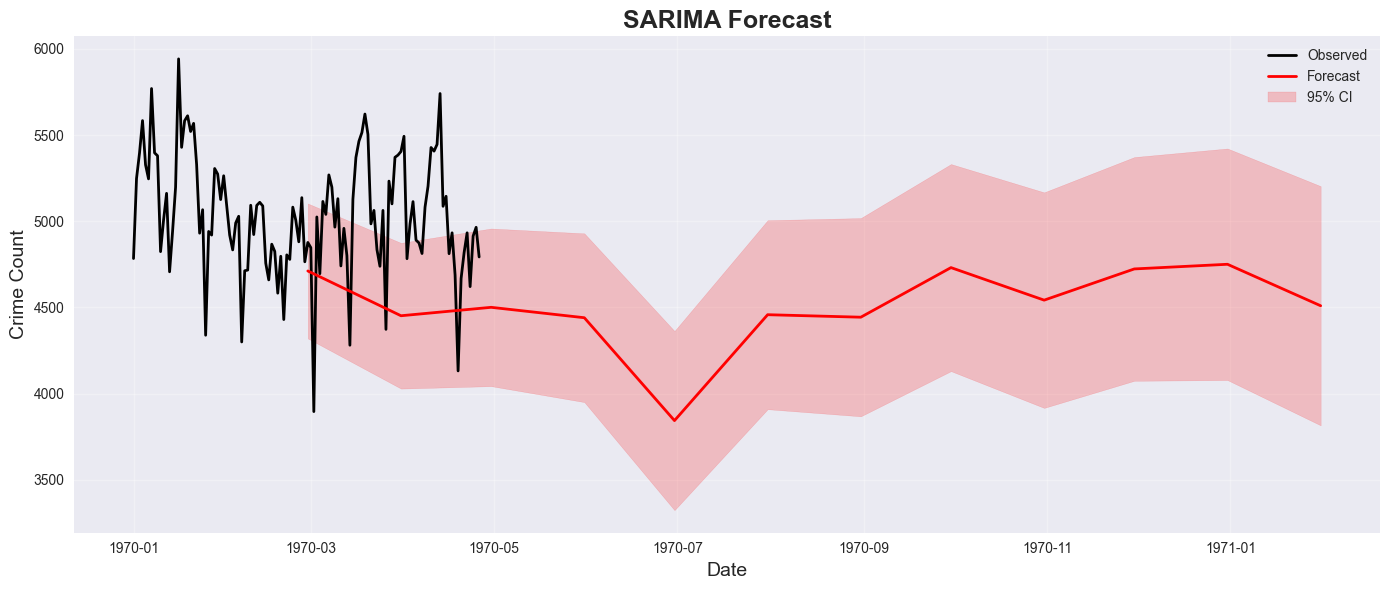

In [96]:
plot_sarima_forecast(results_manual, y=df2['Crime_Count'], steps=12)


In [97]:
def simple_forecast_plot(model, y, steps=12):
    # Forecast
    forecast = model.get_forecast(steps=steps).predicted_mean
    
    # Create future index simply & safely
    future_index = pd.date_range(
        start=y.index[-1],
        periods=steps + 1,
        freq='M'
    )[1:]

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(y.index, y, color='black', label='Observed')
    plt.plot(future_index, forecast, color='red', label='Forecast')

    plt.title("Simple SARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Crime Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

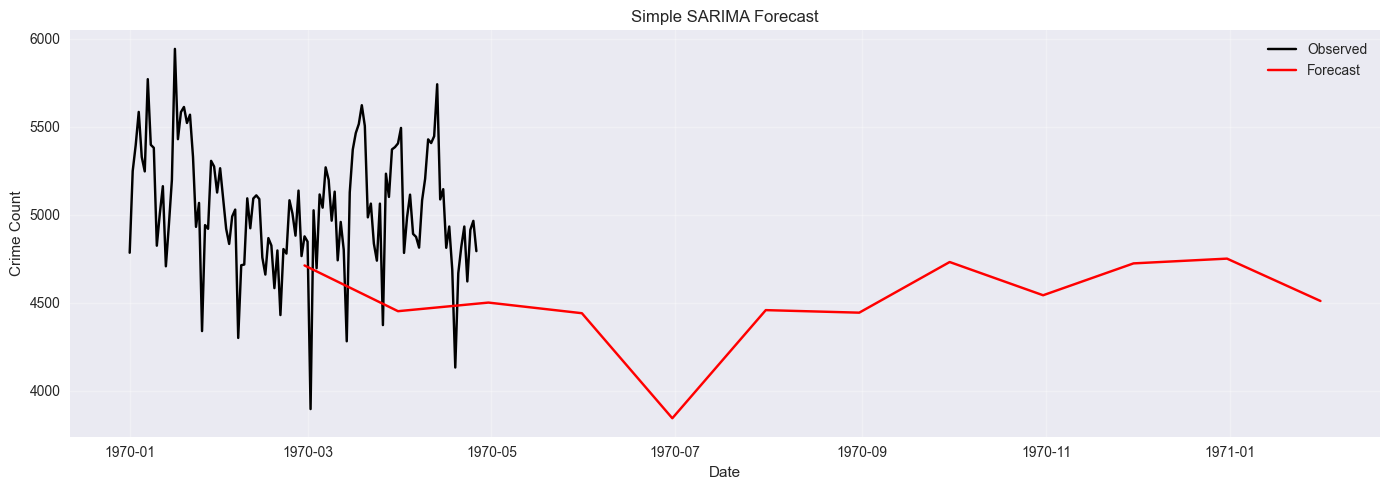

In [98]:
simple_forecast_plot(best_model, df2['Crime_Count'], steps=12)


In [104]:
df_monthly = df2.copy()
df_monthly.head()
# df_monthly['Date'] = pd.to_datetime(df_monthly['Date'])
# df_monthly = df_monthly.set_index('Date')
# df_monthly = df_monthly.asfreq('M')


,Date,Crime_Count
0,2016-02-01,4784.0
1,2016-03-01,5248.0
2,2016-04-01,5396.0
3,2016-05-01,5584.0
4,2016-06-01,5328.0


In [105]:
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'])
df_monthly = df_monthly.set_index('Date')

In [106]:
df_monthly.head()

,Crime_Count
Date,
2016-02-01,4784.0
2016-03-01,5248.0
2016-04-01,5396.0
2016-05-01,5584.0
2016-06-01,5328.0


In [107]:
df_monthly.index

DatetimeIndex(['2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01',
               '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01',
               '2016-10-01', '2016-11-01',
               ...
               '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01',
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01'],
              dtype='datetime64[ns]', name='Date', length=116, freq=None)

In [109]:
def simple_forecast_plot(model, y, steps=12):
    # Forecast
    forecast = model.get_forecast(steps=steps).predicted_mean
    
    # Manually create next month-end dates
    last_date = y.index[-1]
    future_index = pd.DatetimeIndex([
        last_date + pd.offsets.MonthEnd(i) for i in range(1, steps+1)
    ])

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(y.index, y, color='black', label='Observed')
    plt.plot(future_index, forecast, color='red', label='Forecast')

    plt.title("Simple SARIMA Forecast")
    plt.xlabel("Date")
    plt.ylabel("Crime Count")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



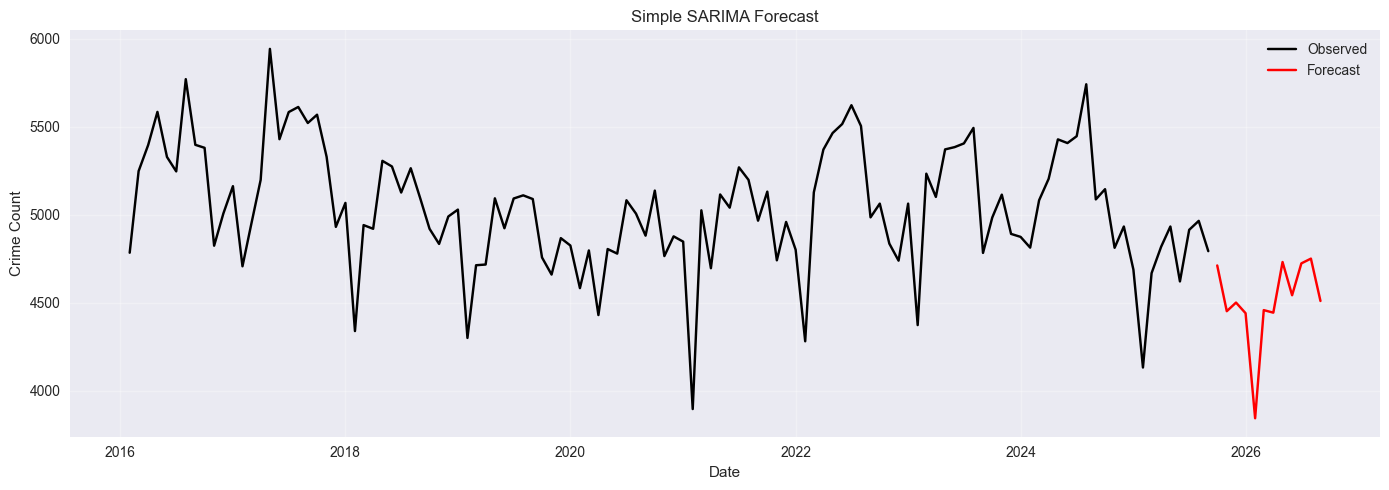

In [110]:
simple_forecast_plot(best_model, df_monthly['Crime_Count'], steps=12)


# Prophet Facebook

In [111]:
# Daily counts
df_daily = (
    df.groupby(df['Date'].dt.date)
      .size()
      .reset_index(name='y')
)

df_daily.rename(columns={'Date': 'ds'}, inplace=True)
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

In [113]:
df_daily.head()

,ds,y
0,2016-02-01,205
1,2016-02-02,185
2,2016-02-03,169
3,2016-02-04,162
4,2016-02-05,167


In [114]:
from prophet import Prophet

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False    # usually False for this kind of data
)

m.fit(df_daily)

Importing plotly failed. Interactive plots will not work.
04:16:23 - cmdstanpy - INFO - Chain [1] start processing
04:16:24 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = m.make_future_dataframe(periods=365, freq='D')
forecast = m.predict(future)

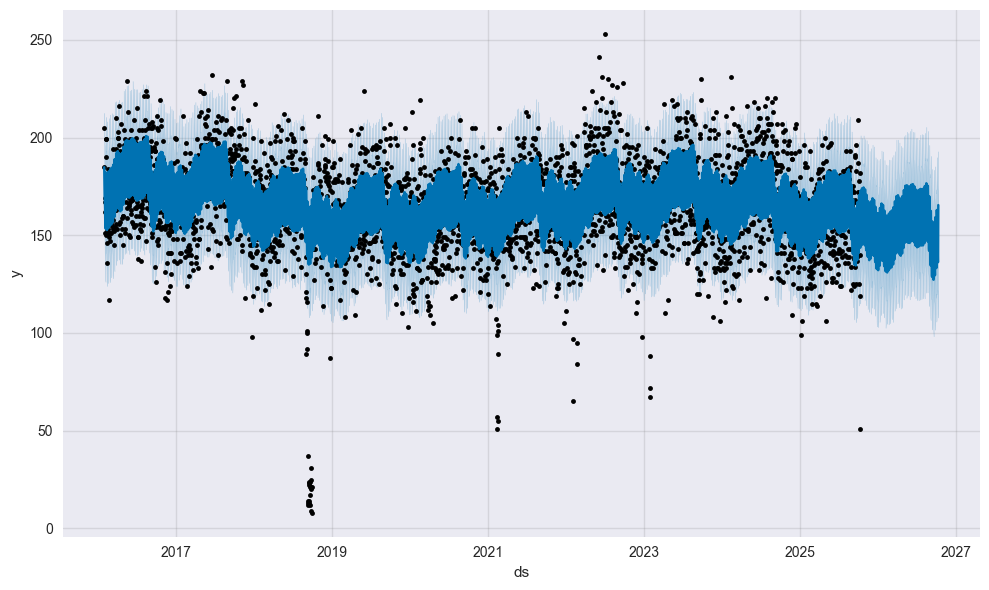

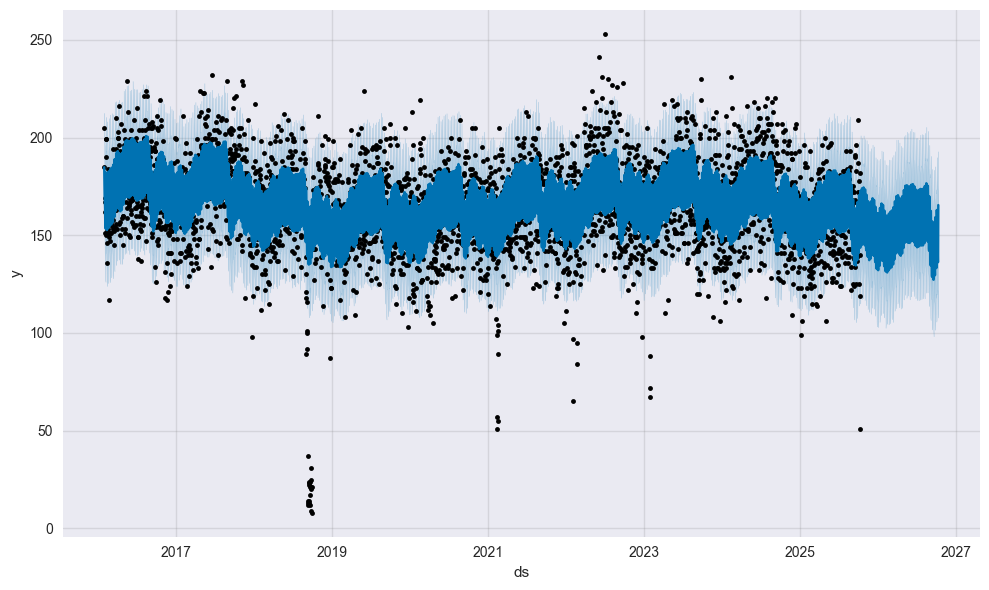

In [117]:
m.plot(forecast)

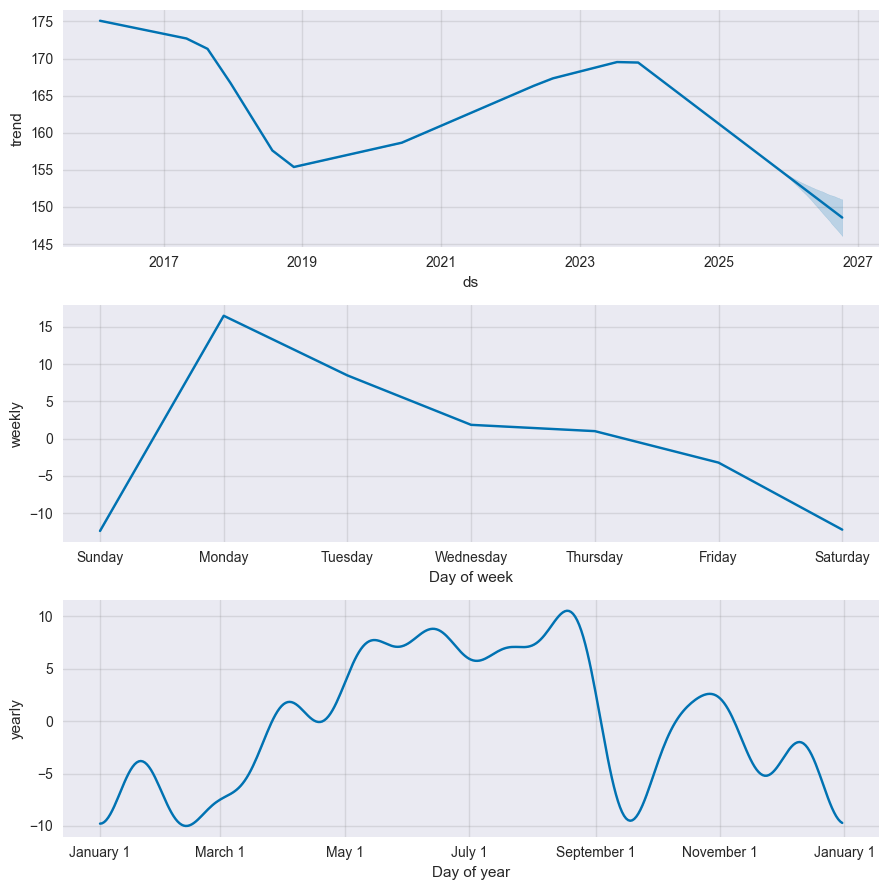

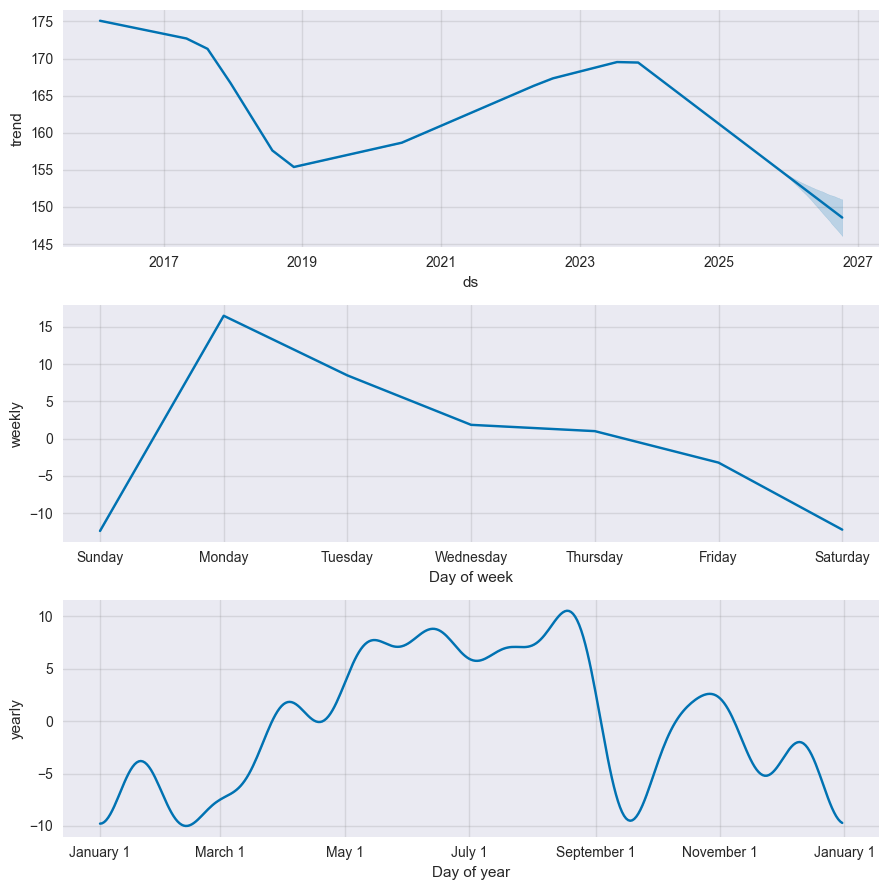

In [118]:
m.plot_components(forecast)